# 9.2.2 多链相关性与有限计算预算

## 学习目标与先修知识

比较初始化、步幅与模态（mode）覆盖，计算基本诊断并解释其限度。

先修：9.2.1的接受步骤，第5.2章方差（variance）与重复实验，第6篇相关时间序列（time series）。

## 具体问题

两条链的轨迹（trajectory）都“稳定”了，它们可能分别困在不同峰，也可能一起困在同一峰。怎样结合轨迹和统计指标发现探索不足？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先看两个没有任何内部波动的序列。即使每个序列的均值都很稳定，它们仍可以互相矛盾。

In [2]:
chains=[[-3.]*10,[3.]*10]
print("两个稳定的链均值：",[np.mean(c) for c in chains])
print("每链内部方差：",[np.var(c) for c in chains])

两个稳定的链均值： [np.float64(-3.0), np.float64(3.0)]
每链内部方差： [np.float64(0.0), np.float64(0.0)]


## 模型假设

沿用等权N(−d,1)、N(d,1)目标，精确均值0、方差1+d²。先固定每链6000步、前1000步作为预热，保留5000步；报告保留长度与总预算。随机种子（random seed）为 902，各链独立抽样。基本 R-hat 采用传统未分割版本，用链内与链间方差作比较。

## 数学解释与推导

相关样本平均值的方差不能直接用独立样本公式。对平稳标量序列且自协方差（covariance）可求和，记ρₖ为自相关，则大样本下
$$\operatorname{Var}(\bar X_N)\approx\frac{\sigma^2}{N}\tau,\qquad \tau=1+2\sum_{k\ge1}\rho_k,\qquad N_{eff}=N/\tau.$$
用固定 K 截断来估计这串自相关之和：用全链中心化平方和作分母，分子用相隔k的乘积和。选择K会影响结果；负相关可使ESS大于N，τ≤0或零方差时报告不可用，不裁剪制造“好指标”。这是链相关性的ESS，与粒子权重的 $1/\sum w_i^2$ 不同。

m条等长链、每条n点，链内无偏方差为sⱼ²、链均值为μⱼ。定义
$$W=m^{-1}\sum_j s_j^2,\quad B=\frac{n}{m-1}\sum_j(\mu_j-\bar\mu)^2,\quad \hat R=\sqrt{\frac{(n-1)W/n+B/n}{W}}.$$
W=0时分母不可用。链间均值分歧通常使R-hat增大，但所有链共同遗漏同一峰时，它也可能接近1。这个有限样本公式有时小于1，不据此声称“超收敛”。

预热是为了减小初值（initial condition）影响的实践安排；丢弃固定步数并不保证已经进入平稳。多链分散初值、轨迹、模式占比、相关性、已知矩参照及独立重复应互补。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)


def mixture_logpdf(value,separation):
    return logsumexp([normal_logpdf(value,-separation,1),normal_logpdf(value,separation,1)])-math.log(2)


def random_walk(initial,increments,uniforms,separation):
    state=initial;path=[state];accepted=[]
    for increment,u in zip(increments,uniforms):
        candidate=state+increment
        take=u==0 or math.log(u)<min(0.,mixture_logpdf(candidate,separation)-mixture_logpdf(state,separation))
        if take:state=candidate
        path.append(state);accepted.append(take)
    return path,accepted


def chain_diagnostics(chains,max_lag):
    m,n=len(chains),len(chains[0]);means=[sum(x)/n for x in chains]
    variances=[sum((x-mean)**2 for x in c)/(n-1) for c,mean in zip(chains,means)]
    W=sum(variances)/m;grand=sum(means)/m
    B=n*sum((mean-grand)**2 for mean in means)/(m-1)
    rhat=math.sqrt(((n-1)*W/n+B/n)/W) if W>0 else None
    ess=[]
    for chain,mean in zip(chains,means):
        denom=sum((x-mean)**2 for x in chain)
        if denom==0:ess.append(None);continue
        correlations=[sum((chain[t]-mean)*(chain[t+k]-mean) for t in range(n-k))/denom for k in range(1,max_lag+1)]
        tau=1+2*sum(correlations)
        ess.append(n/tau if tau>0 else None)
    return rhat,ess

## 对照实验

比较单峰与分离双峰的两条链，并记录模式覆盖。另对单峰目标做30次独立完整运行，报告估计均值的跨运行波动；每次先丢弃1000步。

目标d、基本Rhat、截断ESS： 0.0 1.0007688579475953 [281.35180162426576, 215.85969362525225]


目标d、基本Rhat、截断ESS： 4.0 5.688407684038715 [377.9065132197549, 292.35943024813196]


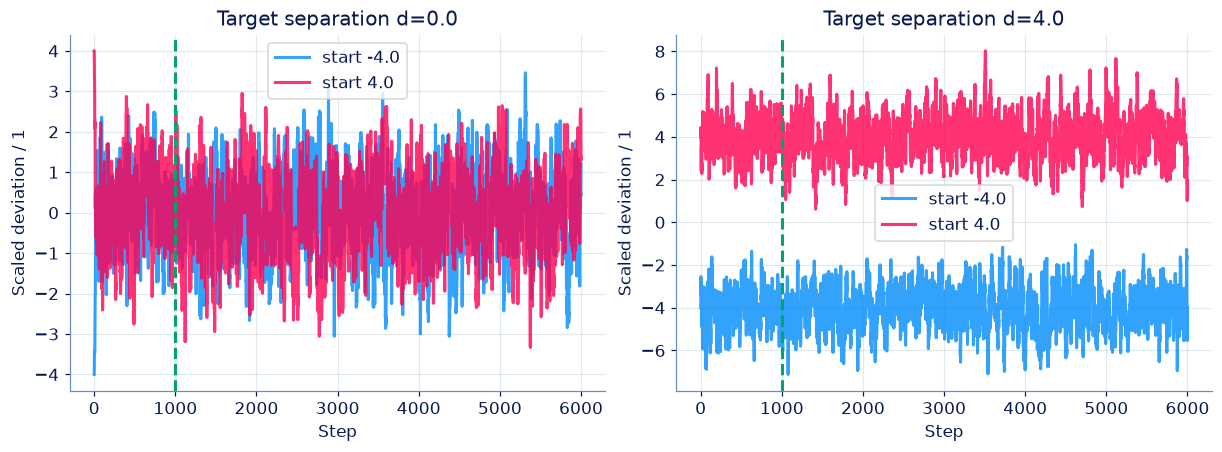

| d | 起点 | 接受率 | 均值 | 右峰侧比例 |
| --- | --- | --- | --- | --- |
| 0 | -4 | 0.8215 | -0.00797902 | 0.4966 |
| 0 | 4 | 0.820333 | -0.0677947 | 0.4854 |
| 4 | -4 | 0.815833 | -4.04656 | 0 |
| 4 | 4 | 0.8135 | 4.01196 | 1 |

30次单峰运行：均值估计的平均、跨运行标准差、平均估计的标准误： -0.004897967985585606 0.036991692146199524 0.00675372807625339


In [4]:
seeds=np.random.SeedSequence(902).spawn(34);fig,axes=plt.subplots(1,2,figsize=(11,4));rows=[]
for j,d in enumerate([0.,4.]):
    group=[]
    for i,start in enumerate([-4.,4.]):
        rng=np.random.default_rng(seeds[2*j+i]);states,accept=random_walk(start,(.6*rng.normal(size=6000)).tolist(),rng.random(6000).tolist(),d)
        keep=states[1001:];group.append(keep);axes[j].plot(states,alpha=.8,label=f'start {start}')
        rows.append((d,start,np.mean(accept),np.mean(keep),np.mean(np.array(keep)>0)))
    rh,ess=chain_diagnostics(group,40);print('目标d、基本Rhat、截断ESS：',d,rh,ess)
    axes[j].axvline(1000,color=GREEN,linestyle='--');axes[j].set(xlabel='Step',ylabel='Scaled deviation / 1',title=f'Target separation d={d}');axes[j].legend()
plt.show();display(Markdown(show_table(['d','起点','接受率','均值','右峰侧比例'],rows)))
replicated=[]
for seed in seeds[4:]:
    rng=np.random.default_rng(seed);states,_=random_walk(0,(1.8*rng.normal(size=6000)).tolist(),rng.random(6000).tolist(),0)
    replicated.append(np.mean(states[1001:]))
print('30次单峰运行：均值估计的平均、跨运行标准差、平均估计的标准误：',np.mean(replicated),np.std(replicated,ddof=1),np.std(replicated,ddof=1)/math.sqrt(30))

## 结果解释

双峰例的局部步幅可能无法在当前预算跨越低密度区；长时间平坦轨迹并不等于完整目标已探索。最后三个数描述“后验（posterior）均值的计算误差”，不是后验本身的标准差（standard deviation）1。单峰对照的重复平均接近 0，双峰中的跨峰困难则提示需要调整步幅或增加预算，再比较采样（sampling）结果。

### 独立核对

用两条四点链手算诊断量，检查常数链与 K=0；再将随机实验的均值及标准误（standard error）与理论矩比较。

In [5]:
rh,es=chain_diagnostics([[0,1,2,3],[1,2,3,4]],1)
np.testing.assert_allclose([rh,*es],[math.sqrt(1.05),8/3,8/3])
assert chain_diagnostics([[1,1,1],[2,2,2]],1)==(None,[None,None])
assert chain_diagnostics([[0,1,0,1],[1,0,1,0]],0)[1]==[4,4]
se=np.std(replicated,ddof=1)/math.sqrt(30)
assert abs(np.mean(replicated))<5*se+.01
print('定义与退化边界通过；重复均值与0在预设宽容差内一致，不认证混合。')

定义与退化边界通过；重复均值与0在预设宽容差内一致，不认证混合。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-02-马尔可夫链采样与诊断/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算基本多链与相关性指标

按正文的有限样本定义计算基本R-hat与截断ESS；它们只是教学诊断，不能认证收敛。

**函数与代码模板**

```python
def solve(
    chains: list[list[float]],
    max_lag: int,
) -> tuple[float | None, list[float | None]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `chains` | `list[list[float]]` | 相同保留长度的多条链，预热已在输入（input）前处理。 | 1 |
| `max_lag` | `int` | 截断自相关求和的最大滞后（lag）。 | 步 |

**返回值**

按以下顺序返回元组：(rhat, ess)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rhat` | <code>float &#124; None</code> | 经典未分割R-hat；W=0时None。 | 1 |
| `ess` | <code>list[float &#124; None]</code> | 每链的截断自相关ESS；零方差（variance）或τ≤0时None。 | 个 |

**计算规则**

每链均值与无偏方差s²；W=mean(s²)，B=n·sum((链均值−总均值)²)/(m−1)，Rhat=sqrt(((n−1)W/n+B/n)/W)。每链ρk=sum(t=0…n−k−1)(xt−均值)(x[t+k]−均值)/sum(xt−均值)²；τ=1+2sum(ρk)，ESS=n/τ。不裁剪ESS或Rhat。

**约束与边界**

- 2—5链；相同长度n为3—100；0≤max_lag<n；数值绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| chains | 相同保留长度的多条链，预热已在输入（input）前处理。 | [[0.0, 1.0, 2.0, 3.0], [1.0, 2.0, 3.0, 4.0]] | 1 |
| max_lag | 截断自相关求和的最大滞后（lag）。 | 1 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
chains = [[0.0, 1.0, 2.0, 3.0], [1.0, 2.0, 3.0, 4.0]]
max_lag = 1

result = solve(chains, max_lag)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rhat | 经典未分割R-hat；W=0时None。 | ≈ 1.024695 | 1 |
| ess | 每链的截断自相关ESS；零方差（variance）或τ≤0时None。 | [2.6666666666666665, 2.6666666666666665] | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.02469507659596,
                   [2.6666666666666665, 2.6666666666666665])
```

**样例解释**

W=5/3、B=2，Rhat=√1.05；每链ρ1=.25，τ=1.5，因此ESS=8/3。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算基本多链与相关性指标](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-basic-diagnostics)

### 第 2 题 · 单项选择题：接受率99%是好消息吗

一条链步幅极小，几乎每次接受，但2000步仍留在起点附近。哪项合理？

- **A.** 高接受率证明后验（posterior）均值精确。
- **B.** 应同时检查移动尺度、自相关、多个初值（initial condition）和计算预算。
- **C.** 删除一半记录必能解决探索问题。
- **D.** 只需延长图像横轴而不生成新样本。

[作答：接受率99%是好消息吗](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-high-acceptance)

### 第 3 题 · 多项选择题：多条链看起来一致

所有链都初始化在双峰目标的左峰，基本Rhat接近1。哪些解释成立？

- **A.** 仍可能全部遗漏右峰。
- **B.** 应从分散初值（initial condition）重新运行，并用网格参考模式质量。
- **C.** Rhat接近1足以证明遍历性。
- **D.** 应报告模式覆盖而不只报告均值诊断。

[作答：多条链看起来一致](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-same-mode)

### 第 4 题 · 单项选择题：两个ESS名字相同

MCMC的相关性ESS与粒子滤波（particle filtering，PF）的1/sum(w²)有什么关系？

- **A.** 都是同一个公式。
- **B.** 前者针对链时间相关，后者针对当前粒子权重集中。
- **C.** 粒子等权就证明MCMC没有自相关。
- **D.** 二者可以替代独立核验。

[作答：两个ESS名字相同](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-ess-not-particles)

### 第 5 题 · 多项选择题：怎样报告随机计算误差

比较两种步幅的后验（posterior）均值估计。哪些做法合理？

- **A.** 使用相同目标和事先固定的密度评估预算。
- **B.** 预先固定多个独立随机种子（random seed）并报告重复估计的离散程度。
- **C.** 只保留最接近参考答案的一次运行。
- **D.** 把计算的标准误（standard error）与后验标准差（standard deviation）区分。

[作答：怎样报告随机计算误差](http://127.0.0.1:8000/chapters/09-02-%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E9%93%BE%E9%87%87%E6%A0%B7%E4%B8%8E%E8%AF%8A%E6%96%AD/practice/?question=p09-budget-repeat)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。 进一步的诊断见[Stan参考手册](https://mc-stan.org/docs/reference-manual/analysis.html)；本节明确保留基础定义的局限。